In [5]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import Counter

In [6]:
df = pd.read_csv("../data/final_table.csv")

In [7]:
df_filtered = df[df["SQ_score"].isin(["min_up", "min_down", "max"])]

# 2. нормализация наборов генов (сортировка)
df_filtered["locus"] = df_filtered["SQ_gene_content_set"].apply(
    lambda x: ",".join(sorted(x.split(",")))
)

# 3. подсчёт уникальных локусов
unique_loci = df_filtered["locus"].nunique()

print("Количество уникальных локусов:", unique_loci)

# 4. таблица частот
locus_counts = df_filtered["locus"].value_counts()
print(locus_counts)

Количество уникальных локусов: 29
locus
sqiA,sqvD,yihV                             15
sqvD,sqwF,sqwG,sqwH,sqwI,yihQ              14
sqvA,sqvD,yihQ,yihU                        14
sqvB,sqvD,sqwF,sqwG,sqwH,sqwI,yihQ         12
sqvA,sqvB,sqvD,yihQ,yihU                   12
sqvD,sqwF,sqwG,sqwH,sqwI                    9
sqvB,sqvD,sqwF,sqwG,sqwH,sqwI               9
sqvA,sqvD                                   8
sqvA,sqvD,sqwG,sqwH                         8
sqvA,sqvB,sqvD                              8
sqiA,sqvB,sqvD,yihV                         7
sqvA,yihQ                                   5
sqvA,sqvB,yihQ,yihU                         5
sqvA,sqvD,yihU                              4
sqiA,sqiK,sqvD                              3
sedA,slaB,sqiA,squF,sqvD,yihV               2
sqvA,yihQ,yihU                              2
sqiA,sqvA,sqvB,sqvD,yihQ,yihU               2
sqvA,sqvB,yihU                              2
sqvA,sqvB,sqvD,sqwF,sqwG,sqwH,sqwI,yihQ     2
sqvA,yihU                               

/tmp/ipykernel_8183/917096147.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["locus"] = df_filtered["SQ_gene_content_set"].apply(


In [8]:
df_filtered["class"] = df_filtered["taxonomy"].apply(
    lambda x: [t for t in x.split(";") if t.startswith("c__")][0].replace("c__", "")
)

/tmp/ipykernel_8183/3691985658.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["class"] = df_filtered["taxonomy"].apply(


In [9]:
df_filtered["locus"] = df_filtered["SQ_gene_content_set"].apply(
    lambda x: ",".join(sorted(x.split(",")))
)

/tmp/ipykernel_8183/2497072862.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["locus"] = df_filtered["SQ_gene_content_set"].apply(


In [10]:
heatmap_df = (
    df_filtered
    .groupby(["class", "locus"])
    .size()
    .unstack(fill_value=0)
)

In [11]:
heatmap_norm = heatmap_df.div(heatmap_df.sum(axis=1), axis=0)

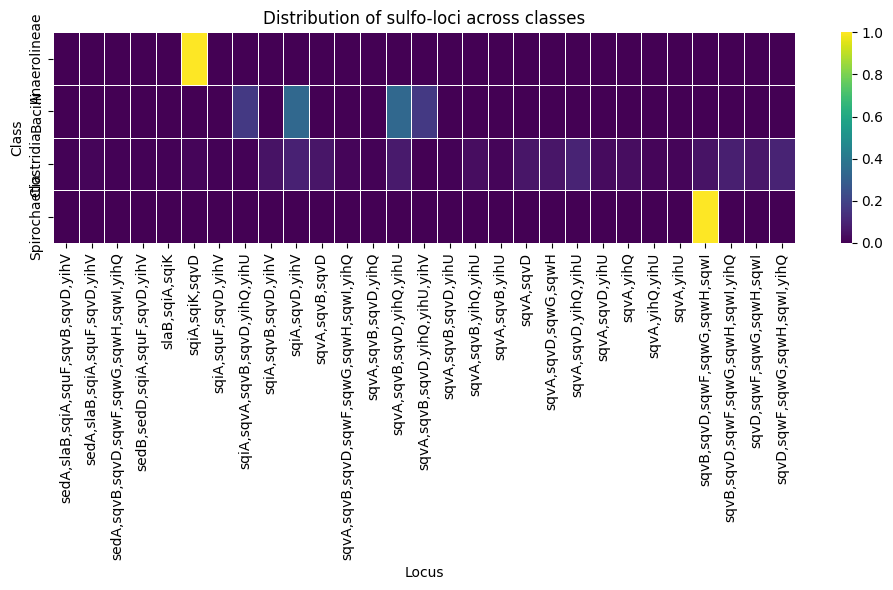

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.heatmap(
    heatmap_norm,  # или heatmap_df если хочешь raw counts
    cmap="viridis",
    linewidths=0.5
)

plt.xlabel("Locus")
plt.ylabel("Class")
plt.title("Distribution of sulfo-loci across classes")

plt.tight_layout()
plt.show()

In [13]:
locus_pathway = (
    df_filtered
    .groupby("locus")["SQ_pathway"]
    .agg(lambda x: x.mode()[0])
)

heatmap_df = (
    df_filtered
    .groupby(["locus", "class"])
    .size()
    .unstack(fill_value=0)
)

heatmap_norm = heatmap_df.div(heatmap_df.sum(axis=1), axis=0)

heatmap_norm["pathway"] = heatmap_norm.index.map(locus_pathway)

heatmap_norm = heatmap_norm.sort_values("pathway")

pathway_labels = heatmap_norm["pathway"]
heatmap_norm = heatmap_norm.drop(columns="pathway")




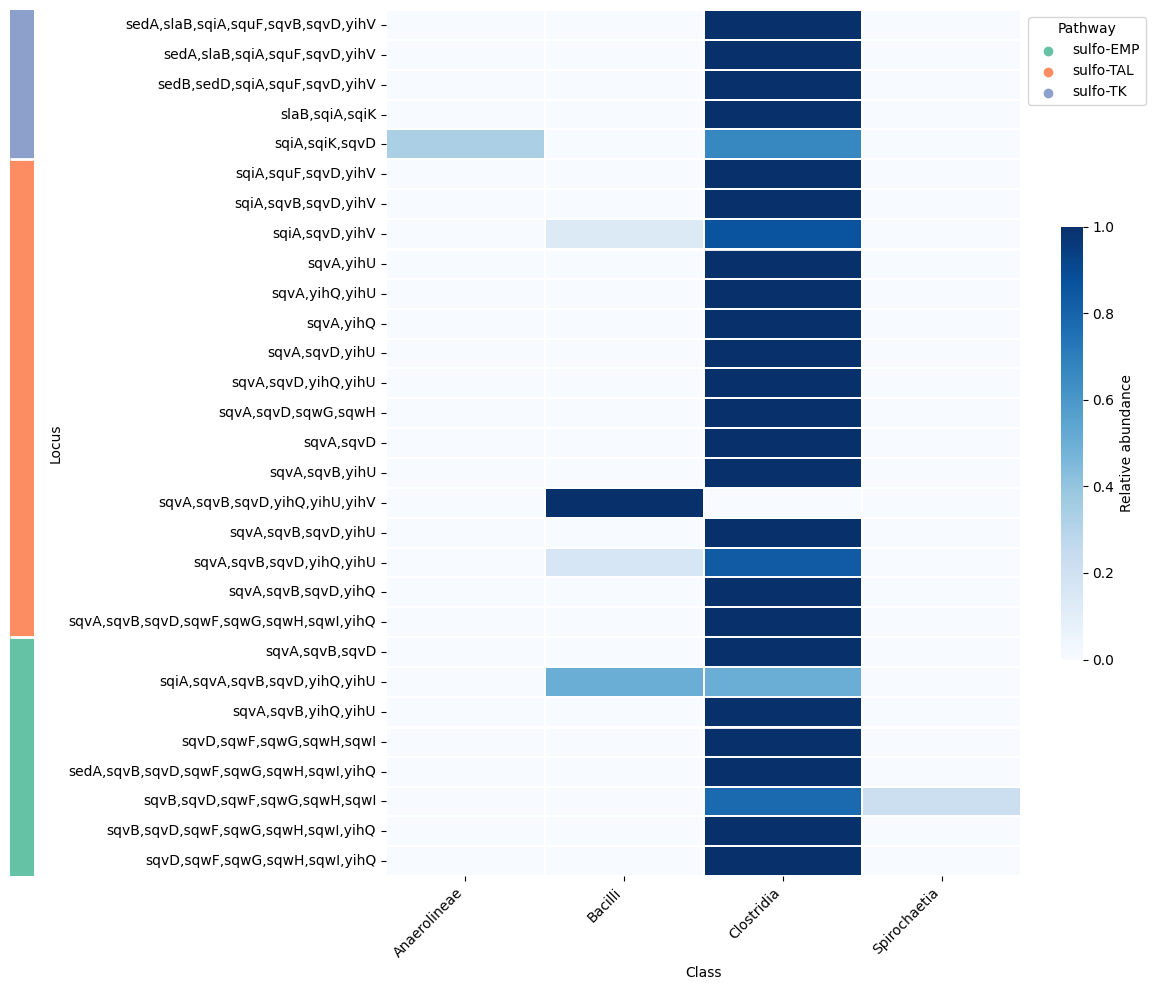

<Figure size 640x480 with 0 Axes>

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- 7. Цвета для pathway ---
pathway_unique = pathway_labels.unique()
palette = sns.color_palette("Set2", len(pathway_unique))

pathway_colors = dict(zip(pathway_unique, palette))
row_colors = pathway_labels.map(pathway_colors)

# --- 8. Создаём фигуру с двумя осями (аннотация + heatmap) ---
fig, (ax_color, ax) = plt.subplots(
    ncols=2,
    figsize=(12, 10),
    gridspec_kw={"width_ratios": [0.3, 10]}
)

# --- 9. Рисуем цветовую полосу pathway ---
for i, color in enumerate(row_colors):
    ax_color.add_patch(plt.Rectangle((0, i), 1, 1, color=color))

ax_color.set_xlim(0, 1)
ax_color.set_ylim(0, len(row_colors))
ax_color.axis("off")

# --- 10. Heatmap ---
sns.heatmap(
    heatmap_norm,
    cmap="Blues",
    ax=ax,
    cbar_kws={
        "label": "Relative abundance",
        "shrink": 0.5,      # уменьшает длину colorbar
        "aspect": 20        # делает его тоньше
    },
    linewidths=0.2
)

# --- 11. Разделители между pathway ---
boundaries = []
prev = pathway_labels.iloc[0]

for i, val in enumerate(pathway_labels):
    if val != prev:
        boundaries.append(i)
        prev = val

for b in boundaries:
    ax.hlines(b, *ax.get_xlim(), colors='white', linewidth=2)
    ax_color.hlines(b, *ax_color.get_xlim(), colors='white', linewidth=2)

# --- 12. Подписи ---
ax.set_xlabel("Class")
ax.set_ylabel("Locus")

ax.set_yticklabels(ax.get_yticklabels(), fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


# --- 13. Легенда pathway ---
for pathway, color in pathway_colors.items():
    ax.scatter([], [], color=color, label=pathway)

ax.legend(
    title="Pathway",
    bbox_to_anchor=(1, 1),  # немного сдвигаем вправо
    loc='upper left'
)
plt.tight_layout()
plt.show()
plt.savefig("../pictures/loci/loci_among_classes.png", dpi=300) 